<a href="https://colab.research.google.com/github/anoushkabhattacharya23/computationalstatistics/blob/main/CSSL_10_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

Let's load the Iris dataset

In [2]:
iris = load_iris()
X_raw = pd.DataFrame(iris.data[:, :4], columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])
y_raw = iris.target
type(iris)

sklearn.utils._bunch.Bunch

Use the below function for plotting. The data that is passed needs to be a pandas dataframe.

In [3]:
# Plotting function
def scatter_helper(data, x_axis_column_name, y_axis_column_name, encoded_class_labels, title):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=data, x=x_axis_column_name, y=y_axis_column_name, hue=encoded_class_labels, palette='viridis', s=70)
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

1. Scale the X_raw using StandardScaler
2. Encode y values using label encoder

In [7]:
# Answer 1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=X_raw.columns)

# Answer 2
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_raw)

3. Scatter the original scaled data along any two features using the above plotting function. Try this step for different combinations of features and identify which pairs of features show correlations. You can use the scatter_helper I have defined above.

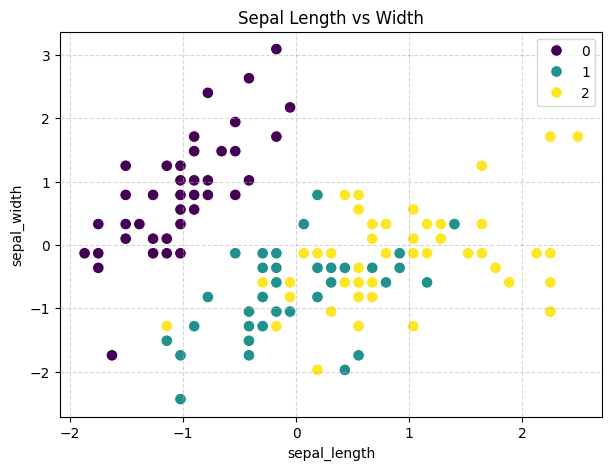

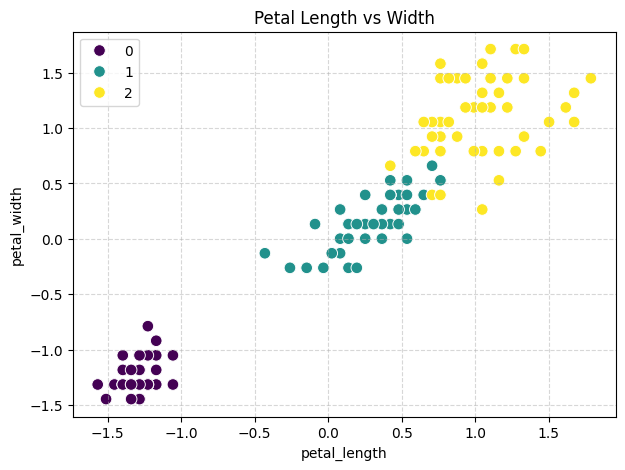

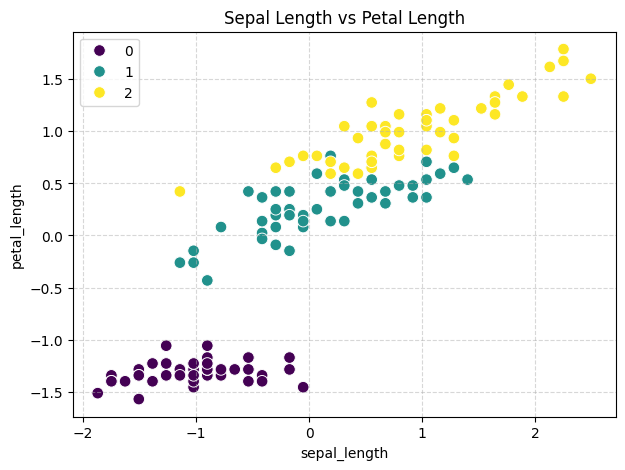

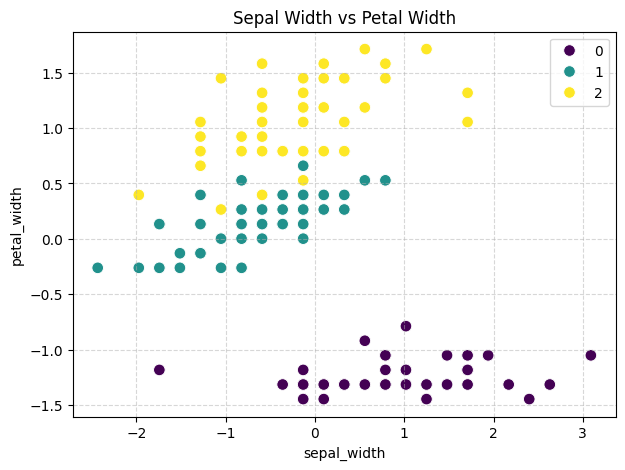

In [9]:
# Answer 3

scatter_helper(X_scaled, "sepal_length", "sepal_width", y_encoded, "Sepal Length vs Width")
scatter_helper(X_scaled, "petal_length", "petal_width", y_encoded, "Petal Length vs Width")
scatter_helper(X_scaled, "sepal_length", "petal_length", y_encoded, "Sepal Length vs Petal Length")
scatter_helper(X_scaled, "sepal_width", "petal_width", y_encoded, "Sepal Width vs Petal Width")



4. Create a PCA model containing as many components as the number of features. Fit-transform the model with the scaled X data.
5. Create a dataframe with the X_pca. Ensure that your give names to different columns, i.e., "PC1", "PC2"...

In [11]:
# Answer 4

pca_model = PCA(n_components=4)
X_pca = pca_model.fit_transform(X_scaled)

# Answer 5
df_X_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3", "PC4"])

5. Scatter the datapoints in the new space with PC1 and PC2 as the new axis. Again, you can take help of the scatter_helper defined above.

**Note:** The y values haven't changed because the class labels aren't used in PCA since it is an unsupervised learning method.

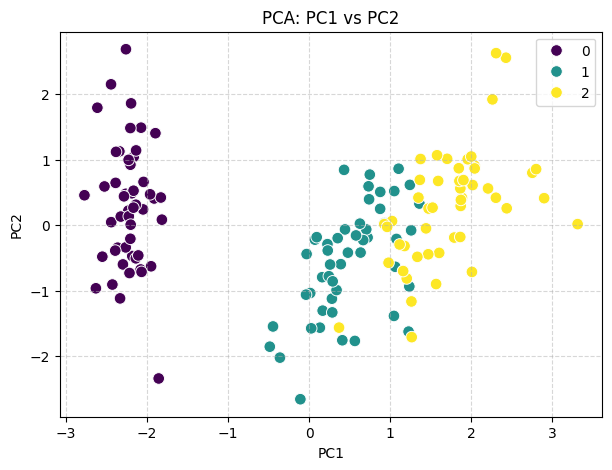

In [13]:
# Answer 5

scatter_helper(df_X_pca, "PC1", "PC2", y_encoded, "PCA: PC1 vs PC2")

6. Plot the scree plot to look at the proportion of variance captured by each PC. In addition, you can plot the cumulative proportion or variance captured by the first n PCs in the same plot using np.cumsum and plt.step

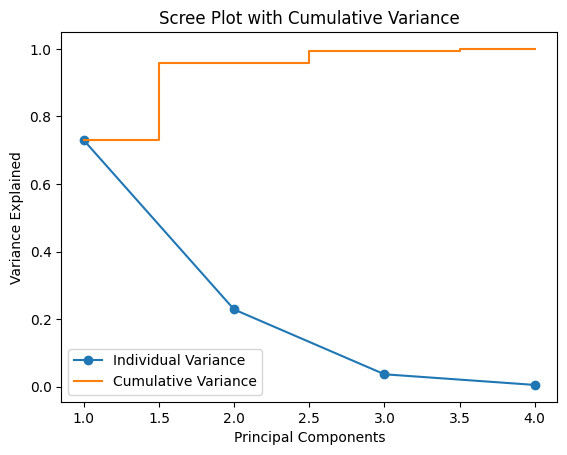

In [14]:
# Answer 6

import numpy as np
explained_var = pca_model.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
plt.figure()
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', label="Individual Variance")
plt.step(range(1, len(cumulative_var)+1), cumulative_var, where='mid', label="Cumulative Variance")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.title("Scree Plot with Cumulative Variance")
plt.legend()

plt.show()

7. Extract the loadings of the components, tranpose them, and visualize them using a heatmap. The seaborn library can be used for visualization.

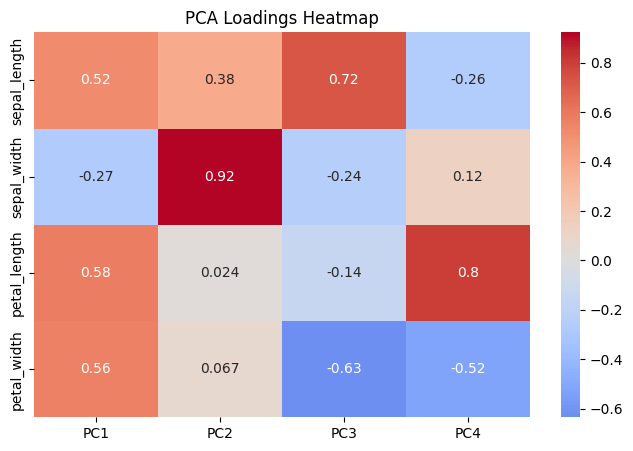

In [15]:
# Answer 7

loadings = pca_model.components_
loadings_T = loadings.T
loadings_df = pd.DataFrame(
    loadings_T,
    columns=["PC1", "PC2", "PC3", "PC4"],
    index=X_raw.columns
)
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.heatmap(loadings_df, annot=True, cmap="coolwarm", center=0)

plt.title("PCA Loadings Heatmap")
plt.show()

In [ ]:
loadings = pd.DataFrame(
    , # transposed PCA components
    columns=,
    index=   # use the feature names form the iris dataset
)

plt.show()


8. Reconstruct the scaled X values from the first two principal components. Hint: Check inverse_transform function from the PCA model

9. Scatter plot pairs of the reconstructed values of the different features (petal length, petal width, sepal length, sepal width). Assess how they compare with the original scaled X values.

10. Compare the mean squared error (reconstruction error) between the original scaled X values and the reconstructed X values.

In [16]:
# Answer 8
X_pca_2 = X_pca.copy()
X_pca_2[:, 2:] = 0
X_reconstructed = pca_model.inverse_transform(X_pca_2)
X_reconstructed_df = pd.DataFrame(X_reconstructed, columns=X_raw.columns)

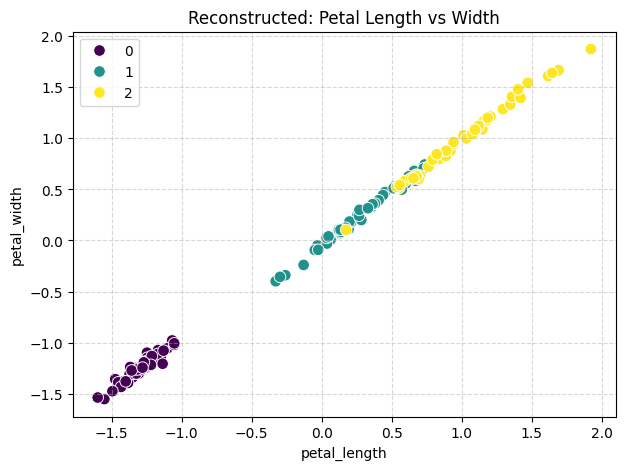

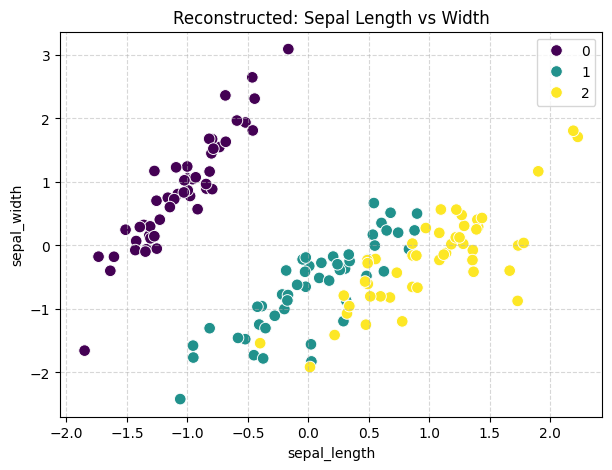

In [17]:
# Answer 9
scatter_helper(X_reconstructed_df, "petal_length", "petal_width", y_encoded, "Reconstructed: Petal Length vs Width")
scatter_helper(X_reconstructed_df, "sepal_length", "sepal_width", y_encoded, "Reconstructed: Sepal Length vs Width")

In [18]:
# Question 10

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(X_scaled, X_reconstructed)
print("Reconstruction MSE:", mse)

Reconstruction MSE: 0.04186792799998359
